In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import load

ROOT = Path.cwd().parents[0]   # notebook inside notebooks/
PROCESSED_DIR = ROOT / "data" / "processed"
PRED_DIR = ROOT / "data" / "predictions"
MODELS_DIR = ROOT / "models"
METRICS_DIR = ROOT / "reports" / "metrics"

PRED_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("features:", (PROCESSED_DIR / "features.parquet").exists())
print("model:", (MODELS_DIR / "lgbm_model.joblib").exists())

ROOT: /Users/sohithmalyala/Desktop/Projects/demand-forecasting-platform
features: True
model: True


In [2]:
df = pd.read_parquet(PROCESSED_DIR / "features.parquet")
df["date"] = pd.to_datetime(df["date"])
print("features shape:", df.shape)

bundle = load(MODELS_DIR / "lgbm_model.joblib")
model = bundle["model"]
feature_cols = bundle["feature_cols"]
print("num features used:", len(feature_cols))


features shape: (57473650, 29)
num features used: 24


In [4]:
X = df[feature_cols].copy()

# safety: ensure object cols become categorical
for c in X.columns:
    if X[c].dtype == "object":
        X[c] = X[c].astype("category")

max_date = df["date"].max()
valid_start = max_date - pd.Timedelta(days=27)
valid_idx = df["date"] >= valid_start

print("valid_start:", valid_start.date(), "valid_end:", max_date.date())
print("valid rows:", int(valid_idx.sum()))

valid_start: 2016-03-28 valid_end: 2016-04-24
valid rows: 853720


In [5]:
pred = model.predict(X.loc[valid_idx])
pred = np.maximum(0, pred).astype(np.float32)

forecast = df.loc[valid_idx, ["id","item_id","store_id","dept_id","cat_id","state_id","date","y"]].copy()
forecast["yhat"] = pred

out_path = PRED_DIR / "forecast.parquet"
forecast.to_parquet(out_path, index=False)

print("✅ saved forecast:", out_path)
print("forecast shape:", forecast.shape)
forecast.head()

✅ saved forecast: /Users/sohithmalyala/Desktop/Projects/demand-forecasting-platform/data/predictions/forecast.parquet
forecast shape: (853720, 9)


,id,item_id,store_id,dept_id,cat_id,state_id,date,y,yhat
1857,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-28,2,0.508803
1858,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-29,1,0.916721
1859,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-30,1,0.946008
1860,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-31,0,0.657374
1861,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-04-01,4,0.650022


In [6]:
def psi(expected, actual, bins=10):
    expected = np.asarray(expected)
    actual = np.asarray(actual)
    expected = expected[np.isfinite(expected)]
    actual = actual[np.isfinite(actual)]
    if len(expected) < 1000 or len(actual) < 1000:
        return None

    q = np.quantile(expected, np.linspace(0, 1, bins + 1))
    q[0] -= 1e-9
    q[-1] += 1e-9

    e_counts, _ = np.histogram(expected, bins=q)
    a_counts, _ = np.histogram(actual, bins=q)

    e_perc = np.clip(e_counts / max(e_counts.sum(), 1), 1e-6, None)
    a_perc = np.clip(a_counts / max(a_counts.sum(), 1), 1e-6, None)

    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))

In [7]:
# Data quality
dq = {
    "rows_features": int(len(df)),
    "duplicate_id_date": int(df.duplicated(["id","date"]).sum()),
    "missing_sell_price_pct": float(df["sell_price"].isna().mean() * 100) if "sell_price" in df.columns else None,
    "negative_y": int((df["y"] < 0).sum()),
}

train_part = df[~valid_idx]
valid_part = df[valid_idx]

drift = {}
for col in ["sell_price", "lag_7", "roll_mean_28"]:
    if col in df.columns:
        drift[col] = {
            "psi": psi(train_part[col].dropna(), valid_part[col].dropna()),
            "train_mean": float(np.nanmean(train_part[col])),
            "valid_mean": float(np.nanmean(valid_part[col])),
        }

# Performance
forecast["abs_err"] = (forecast["y"] - forecast["yhat"]).abs()
performance = {
    "mae": float(forecast["abs_err"].mean()),
    "rmse": float(np.sqrt(np.mean((forecast["y"] - forecast["yhat"])**2))),
    "worst_stores_by_mae_top10": forecast.groupby("store_id")["abs_err"].mean().sort_values(ascending=False).head(10).to_dict(),
    "worst_categories_by_mae": forecast.groupby("cat_id")["abs_err"].mean().sort_values(ascending=False).to_dict(),
}

monitoring = {
    "data_quality": dq,
    "drift": drift,
    "performance": performance,
    "window": {"valid_start": str(valid_start.date()), "valid_end": str(max_date.date())}
}

mon_path = METRICS_DIR / "monitoring.json"
mon_path.write_text(json.dumps(monitoring, indent=2), encoding="utf-8")

print("✅ saved monitoring:", mon_path)
monitoring["performance"]

✅ saved monitoring: /Users/sohithmalyala/Desktop/Projects/demand-forecasting-platform/reports/metrics/monitoring.json


/var/folders/ng/_r0c5xj142dfkh3pgwrw5d_w0000gn/T/ipykernel_18249/3364361826.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "worst_stores_by_mae_top10": forecast.groupby("store_id")["abs_err"].mean().sort_values(ascending=False).head(10).to_dict(),
/var/folders/ng/_r0c5xj142dfkh3pgwrw5d_w0000gn/T/ipykernel_18249/3364361826.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "worst_categories_by_mae": forecast.groupby("cat_id")["abs_err"].mean().sort_values(ascending=False).to_dict(),


{'mae': 0.9905346632003784,
 'rmse': 1.9260014295578003,
 'worst_stores_by_mae_top10': {'CA_3': 1.3111515045166016,
  'WI_2': 1.131873369216919,
  'CA_1': 1.073760986328125,
  'CA_2': 1.068518042564392,
  'WI_1': 0.9428520202636719,
  'TX_2': 0.9350791573524475,
  'WI_3': 0.9159203767776489,
  'TX_3': 0.9090827107429504,
  'TX_1': 0.8388592600822449,
  'CA_4': 0.7782490849494934},
 'worst_categories_by_mae': {'FOODS': 1.2445842027664185,
  'HOUSEHOLD': 0.7772588729858398,
  'HOBBIES': 0.7396152019500732}}

In [8]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parents[0]
forecast = pd.read_parquet(ROOT / "data" / "predictions" / "forecast.parquet")

print(forecast.shape)
forecast.head()

(853720, 9)


,id,item_id,store_id,dept_id,cat_id,state_id,date,y,yhat
0,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-28,2,0.508803
1,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-29,1,0.916721
2,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-30,1,0.946008
3,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-03-31,0,0.657374
4,FOODS_1_001_CA_1_validation,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,2016-04-01,4,0.650022


In [9]:
print("Negative predictions:", (forecast["yhat"] < 0).sum())
print("Mean actual:", forecast["y"].mean())
print("Mean prediction:", forecast["yhat"].mean())

Negative predictions: 0
Mean actual: 1.386433491074357
Mean prediction: 1.3746023


In [10]:
import json

monitoring = json.load(open(ROOT / "reports" / "metrics" / "monitoring.json"))

monitoring.keys()
monitoring["performance"]

{'mae': 0.9905346632003784,
 'rmse': 1.9260014295578003,
 'worst_stores_by_mae_top10': {'CA_3': 1.3111515045166016,
  'WI_2': 1.131873369216919,
  'CA_1': 1.073760986328125,
  'CA_2': 1.068518042564392,
  'WI_1': 0.9428520202636719,
  'TX_2': 0.9350791573524475,
  'WI_3': 0.9159203767776489,
  'TX_3': 0.9090827107429504,
  'TX_1': 0.8388592600822449,
  'CA_4': 0.7782490849494934},
 'worst_categories_by_mae': {'FOODS': 1.2445842027664185,
  'HOUSEHOLD': 0.7772588729858398,
  'HOBBIES': 0.7396152019500732}}

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load model bundle
bundle = load(MODELS_DIR / "lgbm_model.joblib")
model = bundle["model"]
feature_cols = bundle["feature_cols"]

# Get importance
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
0,item_id,74412
17,lag_1,49889
18,lag_7,37336
19,lag_28,34806
23,roll_std_28,21429
7,month,20526
22,roll_mean_28,20214
16,sell_price,16374
3,store_id,14468
21,roll_std_7,12895


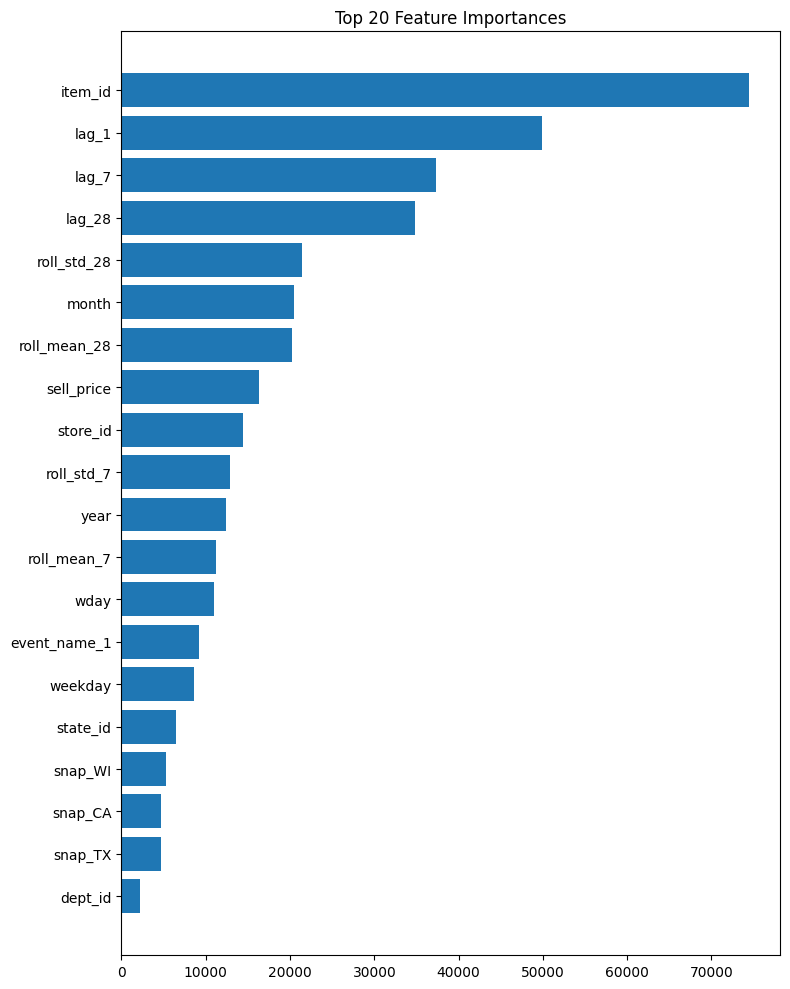

In [13]:
plt.figure(figsize=(8,10))
plt.barh(importance.head(20)["feature"][::-1],
         importance.head(20)["importance"][::-1])
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()